# Lesson 1: NUPACK Basics

NUPACK predicts how nucleic-acid strands fold and interact, using the same kind
of nearest-neighbor thermodynamic model that underlies tools like ViennaRNA, but
built from the ground up to handle **multi-strand complexes** and **test tubes**
of many interacting species.

**By the end of this notebook you will be able to:**

- Build a `Model`, a `Strand`, and a `Complex`, and explain what each represents.
- Run `complex_analysis` to obtain the partition function, the minimum
  free-energy (MFE) structure, and the full base-pair probability matrix.
- Read NUPACK's dot-parens-plus structure notation.
- Read a base-pair probability matrix as a heatmap and as a structure diagram.
- Explain, in your own words, why "the MFE structure" and "the structure" are
  not the same thing.

**Prerequisites:** comfort with Python and basic nucleic-acid vocabulary
(bases, base pairing, secondary structure). No prior NUPACK or ViennaRNA
experience is assumed.


## Introduction

A single RNA or DNA strand does not fold into one rigid shape. At thermal
equilibrium it samples an entire **ensemble** of secondary structures, each
with its own free energy, and spends more time in low-energy structures than
high-energy ones. NUPACK's job is to describe that ensemble quantitatively:
which structures are likely, how much free energy the whole ensemble has, and
- once we add multiple strands - which complexes form at all.

This matters whenever you need to predict or design how a nucleic-acid system
will actually behave: a hairpin used as a thermometer, a pair of strands meant
to bind specifically, or a multi-strand logic gate. "It folds into the
structure I drew" is a *design goal*; NUPACK tells you what the molecule
actually does.

### Roadmap for this series

This notebook is lesson 1 of a 10-lesson NUPACK track (see
`NUPACK_Tutorial_Plan.md`). The series moves in three stages:

1. **Single-complex analysis** (lessons 1-4): one complex, its ensemble, and
   how well a target structure matches that ensemble.
2. **Test-tube analysis** (lessons 5-6): many strands and complexes competing
   for the same building blocks, and how conditions shift that competition.
3. **Design** (lessons 7-10): turning the analysis tools from stages 1-2
   around, to find sequences that behave the way we want.

Today we stay entirely within stage 1, on the smallest possible system: a
single strand folding back on itself.

### Roadmap for this notebook

1. Set up a `Model` describing the physical conditions.
2. Build a `Strand` and a single-strand `Complex`.
3. Run `complex_analysis` and unpack what it returns.
4. Read the MFE structure in dot-parens notation.
5. Read the pair-probability matrix as a heatmap and as a structure diagram.
6. Repeat steps 2-5 on a second sequence whose ensemble is *less* confident,
   to preview why lesson 3 needs the full ensemble, not just the MFE.


## Setup

All examples in this notebook use RNA at 37 deg C ($T = 310.15\,\text{K}$) in
1 M Na$^+$, NUPACK's default-style condition. Later lessons vary temperature,
salt, and strand concentration; for now we fix the physical model once and
reuse it.

We also set a shared plotting theme here (seaborn `whitegrid`) that the rest
of the series reuses, and import [`forgi`](https://github.com/ViennaRNA/forgi)
for RNA-native secondary-structure diagrams - the same library used in the
ViennaRNA track, so structure pictures look consistent across both series.


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import forgi.graph.bulge_graph as fgb
import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)
print(model)


Model('stacking', 'rna06.json', T=310.15 K)


## Theory: the thermodynamic ensemble

NUPACK assigns every possible (pseudoknot-free) secondary structure $s$ of a
complex a free energy $G(s)$, computed from a nearest-neighbor model: the
total energy is a sum of contributions from stacked base pairs, hairpin loops,
bulges, interior loops, and multiloops, each parameterized from melting
experiments. You don't need the individual loop rules to use NUPACK, but you
do need the three quantities they feed into:

**1. The partition function.** Summing Boltzmann factors over *every*
structure $s$ in the set of allowed structures $\Omega$ gives the partition
function

$$
Q = \sum_{s \in \Omega} e^{-G(s) / RT}
$$

where $R$ is the gas constant and $T$ the absolute temperature. $Q$ encodes
the entire ensemble in one number. NUPACK reports it as an **ensemble free
energy**

$$
\Delta G^{\circ}_{\text{ensemble}} = -RT \ln Q ,
$$

which is always **lower** (more negative) than the energy of any single
structure, because it accounts for every accessible fold, not just the best
one.

**2. The minimum free-energy (MFE) structure.** This is simply the single
lowest-energy structure,

$$
\hat{s} = \arg\min_{s \in \Omega} G(s).
$$

It's the structure you'd draw if forced to pick exactly one, and the most
probable single structure in the ensemble - but for longer or more flexible
sequences its probability can still be small in absolute terms.

**3. Base-pair probabilities.** The Boltzmann probability of an individual
structure is $p(s) = e^{-G(s)/RT} / Q$. Summing $p(s)$ over every structure
that contains a particular base pair $(i, j)$ gives the **pair probability**

$$
P_{ij} = \sum_{s \in \Omega:\, (i,j) \in s} p(s), \qquad
P_{ii} = \sum_{s \in \Omega:\, i \text{ unpaired in } s} p(s).
$$

$P_{ij}$ is the fraction of the ensemble in which bases $i$ and $j$ are
paired; $P_{ii}$ (a diagonal entry) is the fraction in which base $i$ is
unpaired. Every row of this matrix sums to 1, because base $i$ is either
unpaired or paired to exactly one partner.

### Connecting theory to code

The `compute=["pfunc", "mfe", "pairs"]` argument to `complex_analysis` below
asks NUPACK for exactly these three quantities:

| Theory | NUPACK result |
| :--- | :--- |
| $\Delta G^{\circ}_{\text{ensemble}} = -RT\ln Q$ | `result.free_energy` |
| $\hat{s}$ and $G(\hat{s})$ | `result.mfe[0].structure`, `result.mfe[0].energy` |
| $P_{ij}$, $P_{ii}$ | `result.pairs.to_array()` |


## Key objects: `Model`, `Strand`, and `Complex`

- A **`Model`** bundles the physical assumptions: material (RNA or DNA),
  temperature, ionic conditions, and the underlying parameter set. We built
  one above; every analysis function takes a `model` argument.
- A **`Strand`** is a named nucleic-acid sequence, written 5' to 3'.
- A **`Complex`** is an ordered collection of strands considered as one
  molecular species - here, just one strand folding on its own.

Our first example is a 13-nt RNA hairpin with a 5-bp stem and a 3-nt loop:
`CGCGC` ... `UUU` ... `GCGCG`. The stem sequence is self-complementary by
design, so we expect a clean hairpin to dominate the ensemble.


In [2]:
hairpin = Strand("CGCGCUUUGCGCG", name="hairpin")
hairpin_complex = Complex([hairpin], name="hairpin_complex")

print("Strand:", hairpin)
print("Length:", len(hairpin), "nt")
print("Complex strands:", [strand.name for strand in hairpin_complex.strands])


Strand: CGCGCUUUGCGCG
Length: 13 nt
Complex strands: ['hairpin']


## First analysis: what structure does this strand prefer?

`complex_analysis` runs one or more analyses over a list of complexes and
returns a result object per complex. We ask for the three quantities from the
theory section above: `pfunc` (partition function / ensemble free energy),
`mfe` (the MFE structure), and `pairs` (the pair-probability matrix).


In [3]:
result = complex_analysis(
    complexes=[hairpin_complex],
    model=model,
    compute=["pfunc", "mfe", "pairs"],
)[hairpin_complex]

mfe = result.mfe[0]

summary = pd.DataFrame(
    [
        {
            "Quantity": "MFE structure  ŝ",
            "Value": str(mfe.structure),
            "Meaning": "Single lowest-energy secondary structure",
        },
        {
            "Quantity": "MFE energy  G(ŝ)",
            "Value": f"{mfe.energy:.2f} kcal/mol",
            "Meaning": "Free energy of that one structure",
        },
        {
            "Quantity": "Ensemble free energy  ΔG°",
            "Value": f"{result.free_energy:.2f} kcal/mol",
            "Meaning": "Free energy of the whole ensemble (-RT ln Q)",
        },
    ]
)

display(summary)


,Quantity,Value,Meaning
0,MFE structure ŝ,(((((...))))),Single lowest-energy secondary structure
1,MFE energy G(ŝ),-6.20 kcal/mol,Free energy of that one structure
2,Ensemble free energy ΔG°,-6.50 kcal/mol,Free energy of the whole ensemble (-RT ln Q)


## Dot-parens(-plus) notation

NUPACK writes secondary structures using **dot-parens notation**, the same
convention used by ViennaRNA:

- `(` and `)` mark a base pair - the $k$-th `(` pairs with the $k$-th matching
  `)`, reading outward (like balanced brackets).
- `.` marks an unpaired base.
- For multi-strand complexes, NUPACK inserts `+` between strands (the
  "-plus" in "dot-parens-plus"); we'll meet that in lesson 2.

For the hairpin, the MFE structure printed above is `(((((...)))))`: five
nested stem pairs, `(1,13)` through `(5,9)`, enclosing a 3-nt loop. Notice that
$G(\hat{s}) = -6.20$ kcal/mol is *higher* (less negative) than
$\Delta G^{\circ} = -6.50$ kcal/mol - the ensemble as a whole is more stable
than its single best structure, exactly as the theory section predicts.


## Visualization: the pair-probability matrix

`result.pairs.to_array()` returns the $N \times N$ matrix $P$ from the theory
section as a NumPy array, indexed from 0. A heatmap of $P$ shows the *entire*
ensemble at a glance: strong off-diagonal bands are confidently paired
regions, and bright diagonal entries are confidently unpaired positions.


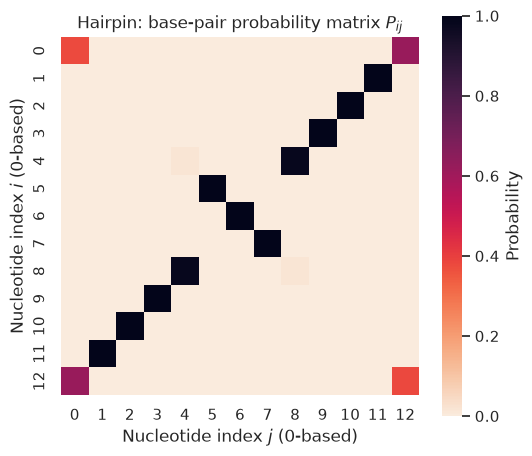

In [4]:
pairs = result.pairs.to_array()

fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(
    pairs,
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Probability"},
    ax=ax,
)
ax.set_title("Hairpin: base-pair probability matrix $P_{ij}$")
ax.set_xlabel("Nucleotide index $j$ (0-based)")
ax.set_ylabel("Nucleotide index $i$ (0-based)")
fig.tight_layout()
plt.show()


**Interpretation.** The bright anti-diagonal band shows the five stem pairs
from the MFE structure: index 0 pairs with 12, 1 with 11, ..., 4 with 8. The
*interior* four pairs (1-11, 2-10, 3-9, 4-8) are each paired with probability
$\ge 0.98$. The *outermost* pair (0, 12) is noticeably less certain - only
about 0.62 - and the corresponding diagonal entries $P_{00} \approx 0.38$ and
$P_{12,12} \approx 0.38$ show that roughly a third of the ensemble has that
terminal pair open instead. This is **end fraying**: terminal base pairs are
stabilized by only one neighboring stack instead of two, so they are
systematically less stable than interior pairs - a pattern you'll see in
almost every stem. The bright diagonal entries for indices 5-7 (the loop)
show those bases are almost always unpaired. Because every base is either
paired to one partner or unpaired, **every row sums to 1**: a row's
probability mass is split between (at most) one off-diagonal cell and its
diagonal cell.

Apart from that expected end-fraying, the heatmap and the MFE structure tell
the same story for this hairpin - the ensemble is dominated by one structure.
That won't always be true, as the second example below shows.


## Visualization: a structure diagram with `forgi`

A probability matrix is precise but abstract. `forgi` turns a dot-bracket
structure into a 2D diagram, laid out so stems are straight helices and loops
form circles - and colors each nucleotide by its structural element (stem,
hairpin loop, interior loop, multiloop, dangling end). We'll reuse this helper
throughout the notebook.


findfont: Failed to find font weight black, now using 700.


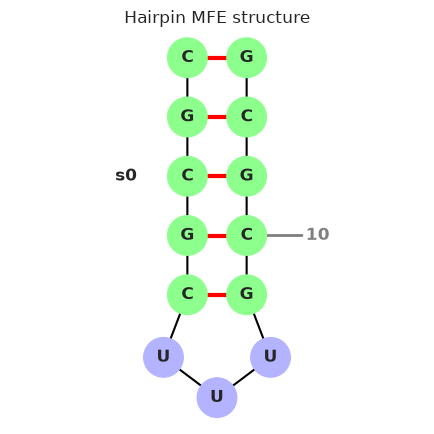

In [5]:
def plot_structure(sequence, structure, ax, title):
    '''Draw a forgi secondary-structure diagram for one dot-bracket structure.'''
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq=sequence)
    fvm.plot_rna(bg, ax=ax, lighten=0.7, text_kwargs={"fontweight": "black"})
    ax.set_title(title)
    ax.set_axis_off()


fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_structure(str(hairpin), str(mfe.structure), ax, "Hairpin MFE structure")
fig.tight_layout()
plt.show()


**Interpretation.** The five-base-pair stem appears as a straight helix
(green, element type "s0"), closed by the 3-nt hairpin loop (blue). This is
the same structure as the dot-parens string `(((((...)))))` and the dominant
band in the heatmap above - three views of one object.


## A second example: when the MFE is not the whole story

The hairpin above was designed to fold cleanly, and its ensemble reflects
that: one structure dominates. Real sequences are rarely so cooperative. Here
is a 21-nt sequence with **two** possible hairpins sharing some structure:


In [6]:
seq2 = "GGGAAACCCAAAGGGAAACCC"
strand2 = Strand(seq2, name="s2")
complex2 = Complex([strand2], name="c2")

result2 = complex_analysis(
    complexes=[complex2],
    model=model,
    compute=["pfunc", "mfe", "pairs"],
)[complex2]

mfe2 = result2.mfe[0]
print("MFE structure:", mfe2.structure)
print(f"MFE energy:        {mfe2.energy:.2f} kcal/mol")
print(f"Ensemble free energy: {result2.free_energy:.2f} kcal/mol")


MFE structure: (((...(((...)))...)))
MFE energy:        -5.80 kcal/mol
Ensemble free energy: -6.05 kcal/mol


The MFE structure `(((...(((...)))...)))` is a nested pair of hairpins -
an outer 3-bp stem enclosing an inner 3-bp stem. But unlike the first
example, this sequence has plenty of self-complementarity to spare: the
outer stem could instead close around the *first* `GGG`/`CCC` pair, or other
combinations. Let's look at the pair-probability matrix and structure diagram
together to see how that ambiguity shows up.


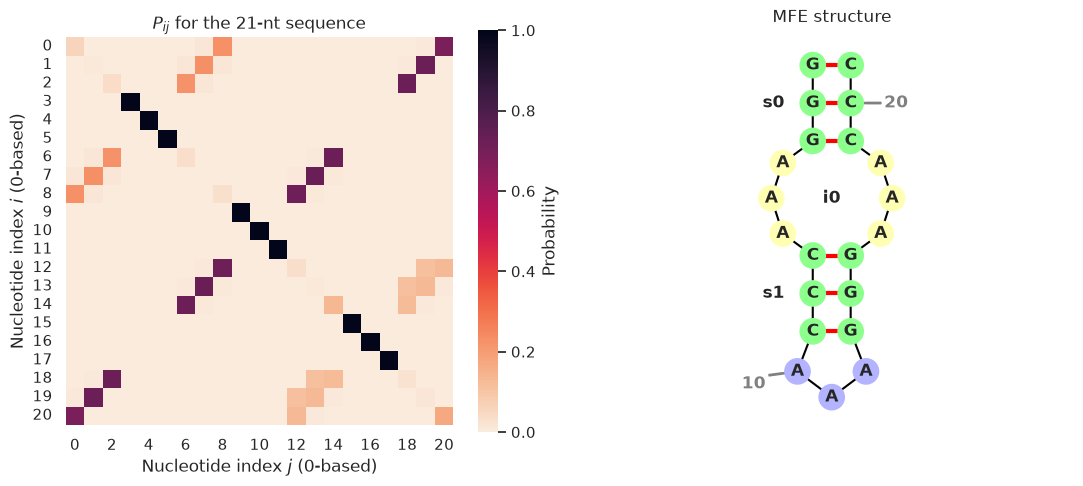

In [7]:
pairs2 = result2.pairs.to_array()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"width_ratios": [1, 1]})

sns.heatmap(
    pairs2,
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Probability"},
    ax=axes[0],
)
axes[0].set_title("$P_{ij}$ for the 21-nt sequence")
axes[0].set_xlabel("Nucleotide index $j$ (0-based)")
axes[0].set_ylabel("Nucleotide index $i$ (0-based)")

plot_structure(seq2, str(mfe2.structure), axes[1], "MFE structure")

fig.tight_layout()
plt.show()


**Interpretation.** Compare the diagonal entries (probability of being
*unpaired*) between the two examples. In the first hairpin, the two
*interior* stem positions (1-4 and 8-11) had $P_{ii} \le 0.02$ - almost never
unpaired - and only the single terminal pair showed real fraying ($\approx
0.38$). Here, **every** stem position (0-2, 6-8, 12-14, 18-20) has
$P_{ii}$ in the 0.01-0.17 range, and the strongest off-diagonal entry in each
of those rows is only **0.69-0.73**, not close to 1.

That means roughly a quarter to a third of the ensemble has each of these
bases either unpaired or paired to a *different* partner than the MFE
structure shows - not just the terminal pairs, but throughout both stems.
The MFE diagram on the right is one valid structure, but the heatmap on the
left is telling you "there's real competition between alternatives here"
- competition that a single dot-bracket string can't show. Lesson 2 picks
this up directly by enumerating those alternative structures.


## Best practices and common pitfalls

- **Don't treat the MFE as "the" structure.** It's the single most probable
  structure, but "most probable" can still mean "30% likely". Always check
  the pair-probability matrix (or, as a single summary number, the *ensemble
  defect* - lesson 4) before trusting the MFE alone.
- **Diagonal entries mean "unpaired", not "self-paired".** A common
  misreading of the pair matrix is to ignore the diagonal; it carries real
  probability mass and rows must sum to 1 including it.
- **RNA vs. DNA alphabets.** `Model(material="rna", ...)` expects `A`, `C`,
  `G`, `U`; `material="dna"` expects `T` instead of `U`. Mixing them raises an
  error rather than silently substituting.
- **`complex_analysis` returns a dict-like object keyed by the `Complex`
  objects you passed in**, in the same order - index it with the `Complex`
  object itself (`result_dict[my_complex]`), not by position, especially once
  you analyze several complexes at once (lesson 2 onward).
- **Energies are free energies, not enthalpies** - they already include
  entropic loop penalties, which is why $\Delta G^{\circ}_{\text{ensemble}}$
  (summing over *all* structures) is always $\le G(\hat{s})$ (the *single*
  best structure).


## Summary

In this notebook you:

1. Built a `Model` describing RNA at 37 deg C in 1 M Na$^+$.
2. Built `Strand` and `Complex` objects for a single-strand hairpin.
3. Ran `complex_analysis(compute=["pfunc", "mfe", "pairs"])` and connected its
   outputs to the partition function $Q$, the MFE structure $\hat{s}$, and the
   pair-probability matrix $P_{ij}$.
4. Read dot-parens notation and a `forgi` structure diagram for the MFE
   structure.
5. Saw a second sequence whose pair-probability matrix revealed competing
   structures that the MFE alone hides.

**Next:** [`02_structural_analysis.ipynb`](02_structural_analysis.ipynb)
enumerates those competing structures directly with suboptimal structure
enumeration, and introduces multi-strand complexes and the `+` in dot-parens-
plus notation.


## Exercises

1. The hairpin `CGCGCUUUGCGCG` has a 3-nt loop (`UUU`). Build the same
   analysis for `CGCGCUUUUGCGCG` (a 4-nt loop, `UUUU`) and `CGCGCUGCGCG` (a
   1-nt loop, `U`). How does the MFE energy change, and does the
   pair-probability matrix stay as confident as the original?
2. For the 21-nt sequence `seq2`, print `result2.pairs.to_array()[0]` (row 0)
   and identify which index has the largest off-diagonal probability. Is it
   the partner that the MFE structure assigns to position 0? By how much does
   the top alternative differ from the MFE pairing probability?
